### Load all simulation complexes

Load all simulation complexes.


In [1]:
import os
from tqdm.notebook import tqdm
import MDAnalysis as mda
import numpy as np
import matplotlib.pyplot as plt

data_dir = "/home/daneel/gitrepos/gromacs_sims/Antimicrobial_Peptides/Pseudomonas_antibiotics/extended_simulations"

simulation_dirs = []
for entry in sorted(os.listdir(data_dir)):
    fullpath = os.path.join(data_dir, entry)
    if os.path.isdir(fullpath):
        simulation_dirs.append(fullpath)



In [2]:
simulation_dirs

['/home/daneel/gitrepos/gromacs_sims/Antimicrobial_Peptides/Pseudomonas_antibiotics/extended_simulations/aminostep2016C',
 '/home/daneel/gitrepos/gromacs_sims/Antimicrobial_Peptides/Pseudomonas_antibiotics/extended_simulations/ndxgyra2018C',
 '/home/daneel/gitrepos/gromacs_sims/Antimicrobial_Peptides/Pseudomonas_antibiotics/extended_simulations/ndxparc2015C',
 '/home/daneel/gitrepos/gromacs_sims/Antimicrobial_Peptides/Pseudomonas_antibiotics/extended_simulations/pbpmez2018C']

Prepare protlig tpr selections for each complex (unless it already exists from old PP)

Now, prepare MDAnalysis universes for each complex

In [4]:
import subprocess
import glob
import re
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

from tqdm.auto import tqdm

complexes = {}

for sys in tqdm(simulation_dirs):
    complex_name = os.path.basename(sys)
    raw_xtc_files = glob.glob(os.path.join(sys, '**/*_cluster_center_traj.xtc'), recursive=True)
    if not raw_xtc_files:
        print(f"No cluster_center_traj.xtc found in {sys}, skipping...")
        continue

    ligname = None
    for f in raw_xtc_files:
        m = re.search(r'prot_' + re.escape(complex_name) + r'_([A-Za-z0-9]+)_', os.path.basename(f))
        if m:
            ligname = m.group(1)
            break

    if not ligname:
        print(f"Couldn't parse ligand name from {sys}, skipping...")
        continue

    tpr_file = os.path.join(sys, f"prot_{complex_name}_{ligname}_gppmd.tpr")
    index_file = os.path.join(sys, f"prot_{complex_name}_{ligname}_index.ndx")
    out_tpr = os.path.join(sys, f"prot_{complex_name}_{ligname}_protlig.tpr")

    if not os.path.exists(out_tpr):
        gmxbinary = "gmx"
        if not os.path.exists(index_file):
            cmd_ndx = [gmxbinary, "make_ndx", "-f", tpr_file, "-o", index_file]
            subprocess.run(cmd_ndx, input="1 | 12\nq\n", text=True, capture_output=True, check=True)

        cmd_conv = [gmxbinary, "convert-tpr", "-s", tpr_file, "-n", index_file, "-o", out_tpr]
        subprocess.run(cmd_conv, input="Protein_Other\n", text=True, capture_output=True, check=True)

    # Sort XTC files chronologically by start time of each trajectory file
    xtc_files = sorted(raw_xtc_files, key=lambda f: mda.Universe(out_tpr, f).trajectory[0].time)

    print(f"{complex_name} (loaded {len(xtc_files)} XTC files chronologically):")
    for fname in xtc_files:
        print(f"  {os.path.basename(fname)}")
    complexes[complex_name] = mda.Universe(out_tpr, xtc_files)

  0%|          | 0/4 [00:00<?, ?it/s]

aminostep2016C (loaded 2 XTC files chronologically):
  prot_aminostep2016C_STM_cluster_center_traj.xtc
  prot_aminostep2016C_STM_md_ext_100ns.part0002_cluster_center_traj.xtc
ndxgyra2018C (loaded 2 XTC files chronologically):
  prot_ndxgyra2018C_NDX_cluster_center_traj.xtc
  prot_ndxgyra2018C_NDX_md_ext_100ns.part0002_cluster_center_traj.xtc
ndxparc2015C (loaded 2 XTC files chronologically):
  prot_ndxparc2015C_NDX_cluster_center_traj.xtc
  prot_ndxparc2015C_NDX_md_ext_100ns.part0002_cluster_center_traj.xtc
pbpmez2018C (loaded 2 XTC files chronologically):
  prot_pbpmez2018C_MEZ_cluster_center_traj.xtc
  prot_pbpmez2018C_MEZ_md_ext_100ns.part0002_cluster_center_traj.xtc


### Calculate all RMSD values and load in a dataframe

Using nproc=6


  0%|          | 0/4 [00:00<?, ?it/s]

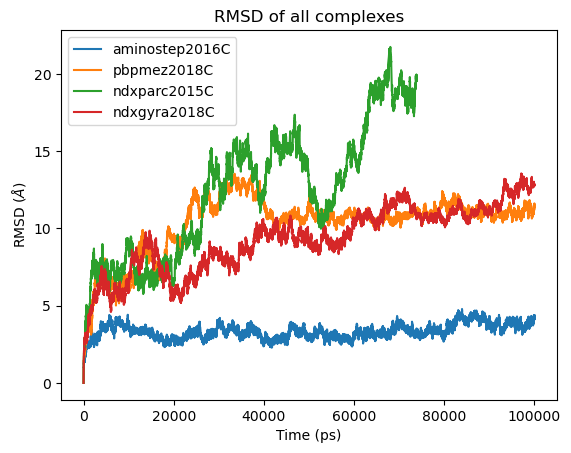

In [12]:
from multiprocessing import Pool, cpu_count
import os
import glob
import pandas as pd
from tqdm.auto import tqdm
import MDAnalysis as mda

def _compute_rmsd_task(args):
    complexname, topol_path, traj_paths = args
    import MDAnalysis as mda
    from MDAnalysis.analysis import rms
    u = mda.Universe(topol_path, traj_paths)
    R = rms.RMSD(u, u, select='backbone', ref_frame=0)
    R.run(verbose=False)
    times = R.results.rmsd[:, 1]
    rmsd = R.results.rmsd[:, 2]
    return complexname, times, rmsd

tasks = []

for d in simulation_dirs:
    topol_files = [f for f in os.listdir(d) if f.endswith('protlig.tpr')]
    if not topol_files:
        continue
    topol_path = os.path.join(d, topol_files[0])
    raw_xtc_files = glob.glob(os.path.join(d, '**/*_cluster_center_traj.xtc'), recursive=True)
    xtc_files = sorted(raw_xtc_files, key=lambda f: mda.Universe(topol_path, f).trajectory[0].time)
    tasks.append((os.path.basename(d), topol_path, xtc_files))

rmsd_series = {}

nproc = min(6, cpu_count())

print(f"Using nproc={nproc}")
with Pool(processes=nproc) as pool:
    for complexname, times, rmsd in tqdm(pool.imap_unordered(_compute_rmsd_task, tasks), total=len(tasks)):
        s = pd.Series(rmsd, index=times)
        rmsd_series[complexname] = s[~s.index.duplicated(keep='first')]

rmsd_df = pd.DataFrame(rmsd_series)
rmsd_df.index.name = 'Time'

rmsd_df.plot(legend=True)
plt.xlabel('Time (ps)')
plt.ylabel(r'RMSD ($\AA$)')
plt.title('RMSD of all complexes')
plt.show()


In [13]:
rmsd_df.head()

,aminostep2016C,pbpmez2018C,ndxparc2015C,ndxgyra2018C
Time,,,,
0.0,0.000000,0.000003,0.000006,0.000002
2.0,0.578932,0.650796,0.623967,0.605027
4.0,0.657709,0.791233,0.746196,0.748672
6.0,0.743575,0.792290,0.867082,0.812744
8.0,0.779477,0.919893,0.976021,0.906662


### Calculate all RMSF and load in a dictionary

In [96]:
import pandas as pd
import MDAnalysis as mda
from MDAnalysis.analysis import rms
import numpy as _np

# build tasks: (complexname, topol_path, traj_path)
tasks = []
for complexname in complexes.keys():
    dirpath = next((d for d in simulation_dirs if os.path.basename(d) == complexname), None)
    if dirpath is None:
        continue
    try:
        topol_files = [f for f in os.listdir(dirpath) if f.endswith('protlig.tpr')]
        if not topol_files:
            continue
        topol_path = os.path.join(dirpath, topol_files[0])
        raw_xtc_files = glob.glob(os.path.join(dirpath, '**/*_cluster_center_traj.xtc'), recursive=True)
        xtc_files = sorted(raw_xtc_files, key=lambda f: mda.Universe(topol_path, f).trajectory[0].time)
    except IndexError:
        # skip if files not found
        continue
    tasks.append((complexname, topol_path, xtc_files))

# worker (override previous broken definition)
def _compute_rmsf_task(args):
    complexname, topol_path, traj_path = args

    u = mda.Universe(topol_path, traj_path)
    sel = u.select_atoms('backbone and name CA')
    R = rms.RMSF(sel).run(verbose=False)
    resids = _np.array(sel.resids)
    rmsf = _np.array(R.results.rmsf)
    return complexname, resids, rmsf

# run in parallel and collect results
rmsf_dict = {}
with Pool(processes=nproc) as p:
    for complexname, resids, rmsf in tqdm(p.imap_unordered(_compute_rmsf_task, tasks), total=len(tasks)):
        rmsf_dict[f'{complexname}_resid'] = resids
        rmsf_dict[f'{complexname}_rmsf'] = rmsf

  0%|          | 0/4 [00:00<?, ?it/s]

### Calculate all Radii of Gyration and load in a dataframe 

Using nproc=6


  0%|          | 0/4 [00:00<?, ?it/s]

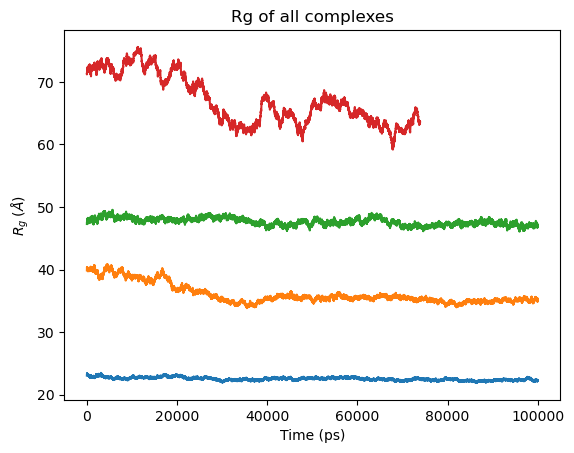

In [11]:
import pandas as pd
from MDAnalysis.analysis import rms
import MDAnalysis as mda
import numpy as _np
# build tasks list of (complexname, topol_path, traj_path) so worker processes create their own Universe
rg_tasks = []
for d in simulation_dirs:
    complexname = os.path.basename(d)
    try:
        topol_files = [f for f in os.listdir(d) if f.endswith('protlig.tpr')]
        if not topol_files:
            continue
        topol_path = os.path.join(d, topol_files[0])
        raw_xtc_files = glob.glob(os.path.join(d, '**/*_cluster_center_traj.xtc'), recursive=True)
        xtc_files = sorted(raw_xtc_files, key=lambda f: mda.Universe(topol_path, f).trajectory[0].time)
    except IndexError:
        # skip directories missing required files
        continue
    rg_tasks.append((complexname, topol_path, xtc_files))

def _compute_rg_task(args):
    complexname, topol_path, traj_path = args
    u = mda.Universe(topol_path, traj_path)
    group = u.select_atoms('protein')
    times = []
    rg = []
    for ts in u.trajectory:
        times.append(ts.time)
        rg.append(group.radius_of_gyration())
    return complexname, _np.array(times), _np.array(rg)

rg_series = {}

nproc = min(6, cpu_count())

print(f"Using nproc={nproc}")
with Pool(processes=nproc) as pool:
    for complexname, times, rg in tqdm(pool.imap_unordered(_compute_rg_task, rg_tasks), total=len(rg_tasks)):
        s = pd.Series(rg, index=times)
        rg_series[complexname] = s[~s.index.duplicated(keep='first')]

rg_df = pd.DataFrame(rg_series)
rg_df.index.name = 'Time'



rg_df.plot(legend=False)
plt.xlabel('Time (ps)')
plt.ylabel(r'$R_g\; (\AA)$')
plt.title('Rg of all complexes')
plt.show()

### Number of hydrogen bonds between protein and ligand

In [118]:
from MDAnalysis.analysis.hydrogenbonds.hbond_analysis import HydrogenBondAnalysis as HBA
import numpy as np
import pandas as pd
import os
from multiprocessing import Pool
import numpy as _np
import MDAnalysis as mda
import warnings
import logging
warnings.filterwarnings("ignore")

logging.getLogger("MDAnalysis").setLevel(logging.ERROR)
logging.getLogger("matplotlib").setLevel(logging.ERROR)

# suppress numpy runtime warnings (e.g. divide by zero, invalid)
_np.seterr(all='ignore')
hb_dict = {}
# build tasks: (complexname, topol_path, traj_path)
tasks_hb = []
for complexname in list(complexes.keys()):
    dirpath = next((d for d in simulation_dirs if os.path.basename(d) == complexname), None)
    if dirpath is None:
        continue
    try:
        topol_files = [f for f in os.listdir(dirpath) if f.endswith('protlig.tpr')]
        if not topol_files:
            continue
        topol_path = os.path.join(dirpath, topol_files[0])
        raw_xtc_files = glob.glob(os.path.join(dirpath, '**/*_cluster_center_traj.xtc'), recursive=True)
        xtc_files = sorted(raw_xtc_files, key=lambda f: mda.Universe(topol_path, f).trajectory[0].time)
    except IndexError:
        continue
    tasks_hb.append((complexname, topol_path, xtc_files))

# Temporarily prevent the serial loop below from executing by emptying complexes,
# we'll restore it after the parallel work.
_orig_complexes = complexes
complexes = {}

def _hba_worker(args):
    complexname, topol_path, traj_path = args
    u = mda.Universe(topol_path, traj_path)
    hbs = HBA(universe=u, update_selections=False)
    hbs.donors_sel = hbs.guess_donors("protein")
    hbs.hydrogens_sel = hbs.guess_hydrogens("protein")
    hbs.acceptors_sel = hbs.guess_acceptors("not protein")
    hbs.run(verbose=False)
    ligand_indices = u.select_atoms(hbs.acceptors_sel).indices

    hbs_reversed = HBA(universe=u, update_selections=False)
    hbs_reversed.donors_sel = hbs.guess_donors("not protein")
    hbs_reversed.hydrogens_sel = hbs.guess_hydrogens("not protein")
    hbs_reversed.acceptors_sel = hbs.guess_acceptors("protein")
    hbs_reversed.run(verbose=False)

    # filter to intermolecular bonds (protein <-> ligand)
    filtered = []
    for hb in hbs.results.hbonds:
        frame, donor_idx, hydrogen_idx, acceptor_idx, da_dist, da_angle = hb
        if (donor_idx not in ligand_indices and acceptor_idx in ligand_indices) or \
        (donor_idx in ligand_indices and acceptor_idx not in ligand_indices):
            filtered.append(hb)

    for hb in hbs_reversed.results.hbonds:
        frame, donor_idx, hydrogen_idx, acceptor_idx, da_dist, da_angle = hb
        if (donor_idx not in ligand_indices and acceptor_idx in ligand_indices) or \
        (donor_idx in ligand_indices and acceptor_idx not in ligand_indices):
            filtered.append(hb)

    filtered = np.array(filtered)

    # counts per frame (nhb)
    times = hbs.times
    print(complexname, times)
    if filtered.size == 0:
        nhb = _np.zeros_like(times, dtype=int)
    else:
        frames = filtered[:, 0].astype(int)
        nhb = _np.bincount(frames, minlength=len(times))[:len(times)]

    n_frames = hbs.n_frames

    # counts by (donor, hydrogen, acceptor)
    if filtered.size == 0:
        count_ids = _np.empty((0, 4), dtype=int)
    else:
        ids = filtered[:, 1:4].astype(int)
        uniq, counts = _np.unique(ids, axis=0, return_counts=True)
        count_ids = _np.hstack((uniq, counts.reshape(-1, 1))).astype(int)

    return complexname, {
        "hbonds": filtered,
        "times": times,
        "nhb": nhb,
        "n_frames": n_frames,
        "count_ids": count_ids,
    }

# Run workers and build hb_dict with lightweight stubs compatible with later code
hb_series = {}
hb_dict = {}
with Pool(processes=nproc) as pool:
    for complexname, data in pool.imap_unordered(_hba_worker, tasks_hb):
        class _HBAStub:
            def __init__(self, d):
                self.results = type("R", (), {})()
                self.results.hbonds = d["hbonds"]
                self.times = d["times"]
                self.n_frames = d["n_frames"]
                self._nhb = d["nhb"]
                self._count_ids = d["count_ids"]
            def count_by_time(self):
                return self._nhb
            def count_by_ids(self):
                return self._count_ids
        s = pd.Series(data["nhb"], index=data["times"])
        hb_series[complexname] = s[~s.index.duplicated(keep='first')]
        hb_dict[complexname] = _HBAStub(data)


complexes = _orig_complexes
        


aminostep2016C [0.0000e+00 2.0000e+00 4.0000e+00 ... 9.9996e+04 9.9998e+04 1.0000e+05]
pbpmez2018C [0.0000e+00 2.0000e+00 4.0000e+00 ... 9.9996e+04 9.9998e+04 1.0000e+05]
ndxgyra2018C [0.0000e+00 2.0000e+00 4.0000e+00 ... 9.9996e+04 9.9998e+04 1.0000e+05]
ndxparc2015C [0.0000e+00 2.0000e+00 4.0000e+00 ... 7.3888e+04 7.3890e+04 7.3892e+04]


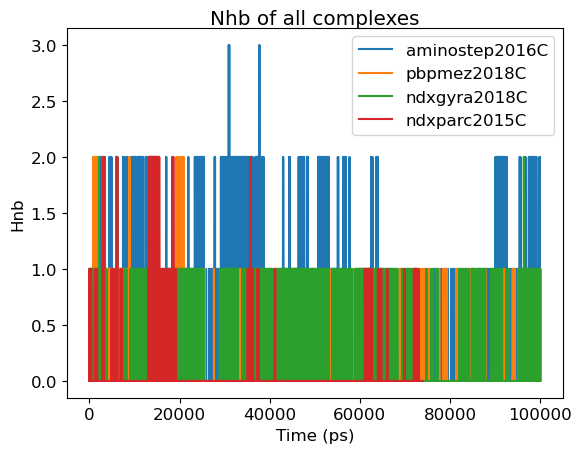

In [119]:
for complex in hb_series.keys():
    plt.plot(hb_series[complex].index, hb_series[complex].values, label=complex)
# Prepare and display the plot.
plt.xlabel('Time (ps)')
plt.ylabel('Hnb')
plt.title('Nhb of all complexes')
plt.legend()
plt.show()

### Plot everything

In [185]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib
import matplotlib.axes as maxes
_original_axis = maxes.Axes.axis

def new_axis(self, *args, **kwargs):
    if args and args[0] == 'off':
        return self  # Skip turning off the axes
    return _original_axis(self, *args, **kwargs)

maxes.Axes.axis = new_axis

colors={'rmsd':'blue', 'rg':'green', 'rmsf':'orange', 'nhb':'gray'}
linestyles={'rmsd':'-', 'rg':'-.', 'rmsf':'--', 'nhb':'-'}
lw = 3
def add_plot(complexname, dataframe, axis, rg_df, nhb_dict, right_ticklabel=False, left_ticklabel=False):
    axis.plot(dataframe.index/1000, dataframe[complexname], label="RMSD (nm)", color=colors['rmsd'], linestyle=linestyles['rmsd'], lw=lw)
    axis.plot(rg_df.index/1000, rg_df[complexname], label=r"$R_g$ (nm)", color=colors['rg'], linestyle=linestyles['rg'], lw=lw)
    axis.set_xticks(dataframe.index[::int(len(dataframe)/4)]/1000)
    # Round the tick labels to integers for better readability
    axis.set_xticklabels(["{:.0f}".format(x) for x in dataframe.index[::int(len(dataframe)/4)]/1000])
    
    ax_right = axis.twinx()
    ax_right.plot(nhb_dict[complexname].index/1000, nhb_dict[complexname].values, label=r"$N_{hb}$", color=colors['nhb'], alpha=0.5, linestyle=linestyles['nhb'], lw=lw)
    ax_right.set_ylim(0, 3.1)
    ticks = [0,1,2,3]
    ax_right.set_yticks(ticks)
    ax_right.tick_params(axis='both', which='both', direction='in', length=12, width=2.5)
    if right_ticklabel:
        ax_right.set_yticklabels(["{:.0f}".format(x) for x in ticks])
        ax_right.set_ylabel(r"$N_{hb}$", fontsize=14)
    else:
        ax_right.set_yticklabels([])

    if left_ticklabel:
        axis.set_ylabel(r"RMSD / $R_g$ ($\AA$)", fontsize=14)


def add_rmsfplot(complexname, axis, rmsf_dict, tick_xlabel=False, tick_ylabel=False,verbose=False):
    axis.plot(rmsf_dict[f"{complexname}_resid"], rmsf_dict[f"{complexname}_rmsf"], label=r"$RMSF\;(\AA)$", color=colors['rmsf'], linestyle=linestyles['rmsf'], lw=lw)
    
    if verbose:
        print(f"Plotting RMSF for {complexname}: residue ids {rmsf_dict[f'{complexname}_resid'][0]} to {rmsf_dict[f'{complexname}_resid'][-1]}")
    ticks = np.linspace(rmsf_dict[f"{complexname}_resid"][0], rmsf_dict[f"{complexname}_resid"][-1], 4)
    axis.set_xticks(ticks)
    axis.tick_params(axis='both', which='both', direction='in', length=12, width=2.5)
    axis.set_xticklabels(["{:.0f}".format(x) for x in ticks])
    if tick_xlabel:
        axis.set_xlabel("Residue id", fontsize=14)
    if tick_ylabel:
        axis.set_ylabel(r"RMSF ($\AA$)", fontsize=14)
    

### Hydrogen Bond occupancy statistics

In [120]:
from tqdm.notebook import tqdm
hb_details = {}

for complex, hb in tqdm(hb_dict.items()):
    u = complexes[complex]
    ligand_indices = u.select_atoms('not protein').indices
    ligand_names = u.select_atoms('not protein').resnames
    hbstats = hb.count_by_ids()
    # Only keep bonds with occupancy more than 0.1%
    hbstats_filtered = hbstats[hbstats[:, -1] / hb.n_frames > 0.001]
    bond_types = []
    for bond in hbstats_filtered:
        donor_idx, hydrogen_idx, acceptor_idx, occ = bond
        donor_atom = u.atoms[int(donor_idx)]
        hydrogen_atom = u.atoms[int(hydrogen_idx)]
        acceptor_atom = u.atoms[int(acceptor_idx)]
        # Check if the donor or acceptor is a ligand
        if donor_idx in ligand_indices and acceptor_idx not in ligand_indices:
            # Donor is a ligand, acceptor is not
            bond_type = f"({donor_atom.resname}){donor_atom.name}-H::{acceptor_atom.name}({acceptor_atom.resid}-{acceptor_atom.resname}) : {occ/hb.n_frames:.3f}"
        elif acceptor_idx in ligand_indices and donor_idx not in ligand_indices:
            # Acceptor is a ligand, donor is not
            bond_type = f"({donor_atom.resid}-{donor_atom.resname}){donor_atom.name}-H::{acceptor_atom.name}({acceptor_atom.resname}) : {occ/hb.n_frames:.3f}"
        else:
            # Both donor and acceptor are ligands
            continue
        bond_types.append(bond_type)
    
    hb_details[complex] = bond_types

  0%|          | 0/4 [00:00<?, ?it/s]

### Save the hydrogen bond data to a json file so you don't have to keep calculating it

In [121]:
import json

outpath = os.path.join(data_dir, "hb_details.json")
with open(outpath, "w") as fh:
    json.dump(hb_details, fh, indent=2)
print(f"Saved hb_details to {outpath}")

Saved hb_details to /home/daneel/gitrepos/gromacs_sims/Antimicrobial_Peptides/Pseudomonas_antibiotics/extended_simulations/hb_details.json


### Load the hbonds info from json file to plot

In [123]:
import json
from pprint import pprint
import os
import re
import pandas as pd
from IPython.display import display

hb_json_path = "/home/daneel/gitrepos/gromacs_sims/Antimicrobial_Peptides/Pseudomonas_antibiotics/extended_simulations/hb_details.json"

if not os.path.exists(hb_json_path):
    raise FileNotFoundError(f"Hydrogen-bond JSON not found: {hb_json_path}")

with open(hb_json_path, "r") as fh:
    hb_details_loaded = json.load(fh)

print(f"Loaded {len(hb_details_loaded)} complexes from {hb_json_path}")
# build a hierarchical (MultiIndex) table from hb_details_loaded

rows = []
for complex_name, bonds in hb_details_loaded.items():
    if not bonds:
        rows.append({
            'complex': complex_name,
            'bond_idx': 0,
            'bond_str': '',
            'donor_resid': None,
            'donor_resname': None,
            'donor_atom': None,
            'acceptor_atom': None,
            'acceptor_resname': None,
            'occupancy': None,
        })
        continue
    for i, b in enumerate(bonds):
        if not b or not b.strip():
            continue
        m = re.match(
            r'\((?P<don_resid>\d+)-(?P<don_resname>[^)]+)\)'
            r'(?P<don_atom>[^-]+)-H::(?P<acc_atom>[^(]+)\('
            r'(?P<acc_resname>[^)]+)\)\s*:\s*(?P<occ>[\d.]+)',
            b
        )
        if m:
            gd = m.groupdict()
            rows.append({
                'complex': complex_name,
                'bond_idx': i,
                'bond_str': b,
                'donor_resid': int(gd['don_resid']),
                'donor_resname': gd['don_resname'],
                'donor_atom': gd['don_atom'],
                'acceptor_atom': gd['acc_atom'].strip(),
                'acceptor_resname': gd['acc_resname'],
                'occupancy': float(gd['occ'])
            })
        else:
            # fallback: keep raw string and split off trailing occupancy if present
            parts = [p.strip() for p in b.rsplit(":", 1)]
            occ = None
            if len(parts) == 2:
                try:
                    occ = float(parts[1])
                except Exception:
                    occ = None
            rows.append({
                'complex': complex_name,
                'bond_idx': i,
                'bond_str': b,
                'donor_resid': None,
                'donor_resname': None,
                'donor_atom': None,
                'acceptor_atom': None,
                'acceptor_resname': None,
                'occupancy': occ
            })

df_hb = pd.DataFrame(rows)
df_hb.set_index(['complex', 'bond_idx'], inplace=True, drop=True)
# sort for nicer display
df_hb.sort_index(inplace=True)

# show the hierarchical table
display(df_hb)

out_xlsx = os.path.join(os.path.dirname(hb_json_path), "hb_details.xlsx")
os.makedirs(os.path.dirname(out_xlsx), exist_ok=True)
try:
    df_hb.to_excel(out_xlsx, sheet_name="hbonds")
    print(f"Saved hb dataframe to {out_xlsx}")
except Exception as e:
    print(f"Failed to save Excel file: {e}")

Loaded 4 complexes from /home/daneel/gitrepos/gromacs_sims/Antimicrobial_Peptides/Pseudomonas_antibiotics/extended_simulations/hb_details.json


bond_str  donor_resid  \
complex        bond_idx                                                 
aminostep2016C 0           (26-SER)OG-H::N6(STM) : 0.006           26   
               1          (26-SER)OG-H::O11(STM) : 0.003           26   
               2          (67-ASN)ND2-H::N1(STM) : 0.004           67   
               3          (67-ASN)ND2-H::N3(STM) : 0.002           67   
               4          (67-ASN)ND2-H::O4(STM) : 0.045           67   
               5          (89-GLN)NE2-H::N3(STM) : 0.003           89   
               6          (217-SER)OG-H::N1(STM) : 0.002          217   
               7          (217-SER)OG-H::N5(STM) : 0.246          217   
               8          (217-SER)OG-H::O5(STM) : 0.010          217   
               9          (217-SER)OG-H::N6(STM) : 0.003          217   
ndxgyra2018C   0         (543-THR)OG1-H::O2(NDX) : 0.244          543   
               1         (543-THR)OG1-H::O3(NDX) : 0.030          543   
ndxparc2015C   0         (100-ARG)NH1-H::O2(NDX) : 0.002          100   
               1          (163-SER)OG-H::O1(NDX) : 0.003          163   
               2         (219-ARG)NH1-H::O1(NDX) : 0.004          219   
               3         (450-ARG)NH1-H::N1(NDX) : 0.021          450   
               4         (450-ARG)NH1-H::O1(NDX) : 0.003          450   
               5         (450-ARG)NH2-H::O1(NDX) : 0.001          450   
               6         (450-ARG)NH2-H::N2(NDX) : 0.023          450   
pbpmez2018C    0          (327-SER)OG-H::O5(MEZ) : 0.004          327   
               1         (327-SER)OG-H::OXT(MEZ) : 0.002          327   
               2         (452-GLN)NE2-H::O4(MEZ) : 0.008          452   
               3          (452-GLN)NE2-H::O(MEZ) : 0.017          452   
               4         (549-GLN)NE2-H::O3(MEZ) : 0.015          549   

                        donor_resname donor_atom acceptor_atom  \
complex        bond_idx                                          
aminostep2016C 0                  SER         OG            N6   
               1                  SER         OG           O11   
               2                  ASN        ND2            N1   
               3                  ASN        ND2            N3   
               4                  ASN        ND2            O4   
               5                  GLN        NE2            N3   
               6                  SER         OG            N1   
               7                  SER         OG            N5   
               8                  SER         OG            O5   
               9                  SER         OG            N6   
ndxgyra2018C   0                  THR        OG1            O2   
               1                  THR        OG1            O3   
ndxparc2015C   0                  ARG        NH1            O2   
               1                  SER         OG            O1   
               2                  ARG        NH1            O1   
               3                  ARG        NH1            N1   
               4                  ARG        NH1            O1   
               5                  ARG        NH2            O1   
               6                  ARG        NH2            N2   
pbpmez2018C    0                  SER         OG            O5   
               1                  SER         OG           OXT   
               2                  GLN        NE2            O4   
               3                  GLN        NE2             O   
               4                  GLN        NE2            O3   

                        acceptor_resname  occupancy  
complex        bond_idx                              
aminostep2016C 0                     STM      0.006  
               1                     STM      0.003  
               2                     STM      0.004  
               3                     STM      0.002  
               4                     STM      0.045  
               5                     STM      0.003  


Failed to save Excel file: No module named 'openpyxl'


## Plot everything

In [141]:
import numpy as np
import matplotlib.pyplot as plt

# Gantt-style horizontal bars for bonds, with the bond string displayed inside each bar
def plot_gantt(axis, bond_list, set_xlabel=False, xlim=(-0.01, 0.75), set_ylabel=False):
    # parse labels and occupancies
    labels = [b.split(" : ")[0] for b in bond_list]
    occs = np.array([float(b.split(" : ")[1]) for b in bond_list])

    # sort by occupancy descending for nicer layout
    order = np.argsort(-occs)
    labels = [labels[i] for i in order]
    occs = occs[order]

    y = np.arange(len(labels))
    bars = axis.barh(y, occs, color='lightblue', edgecolor='black', height=1)

    # put the bond string inside each bar (or just to the right if bar too small)
    for idx, (bar, lbl, val) in enumerate(zip(bars, labels, occs)):
        width = bar.get_width()
        x_text = width * 0.5
        # decide text color for contrast
        text_color = "black"
        if width < 0.3:
            # place label just right of the bar for very small bars
            x_text = width + 0.005
            ha = "left"
        else:
            ha = "center"
        axis.text(x_text, bar.get_y() + bar.get_height() / 2, lbl, va="center", ha=ha, color=text_color, fontsize=7, clip_on=True)
    
    if set_xlabel:
        axis.set_xlabel("Occupancy (fraction)", fontsize=14)
    if set_ylabel:
        axis.set_ylabel("Hydrogen Bonds", labelpad=20, fontsize=14)

    axis.set_xlim(xlim)
    axis.set_yticks([])
    axis.set_yticklabels([])  # labels are shown inside bars
    ymin, ymax = axis.get_ylim()
    axis.set_ylim(ymin - 0.5, ymax + 0.5)
    axis.invert_yaxis()  # highest occupancy at top (optional)


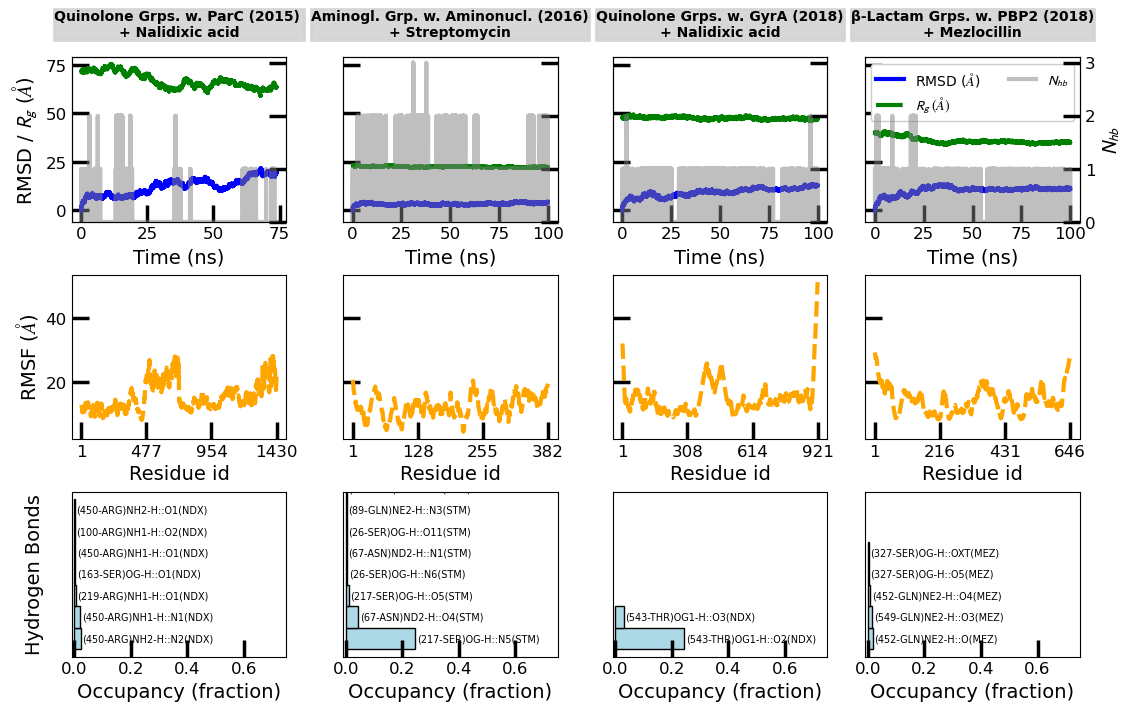

In [186]:
# language: python
import re
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec
import matplotlib as mpl
mpl.rcParams['axes.titlepad'] = 0
mpl.rcParams['font.family'] = 'Carlito'
mpl.rcParams['font.serif'] = ['Carlito']
mpl.rcParams['font.size'] = 12
mpl.rcParams['mathtext.fontset'] = 'stixsans'
mpl.rcParams['text.usetex'] = False
from matplotlib.patches import FancyBboxPatch
from matplotlib import lines as mlines



default_ylim = (-6, 79)
default_yticks = [0, 25, 50, 75]

fig, axs = plt.subplots(nrows=3, ncols=4, figsize=np.array([16, 10])*0.7, sharey="row", constrained_layout=True)


# Right legend / annotation column
legend_ax = axs[0][-1]
handles = [
    mlines.Line2D([0], [0], color=colors['rmsd'], lw=lw, linestyle=linestyles['rmsd']),
    mlines.Line2D([0], [0], color=colors['rg'], lw=lw, linestyle=linestyles['rg']),
    mlines.Line2D([0], [0], color=colors['nhb'], lw=lw, alpha=0.5, linestyle=linestyles['nhb']),
]
labels = [r"RMSD ($\AA$)", r"$R_g\;(\AA)$", r"$N_{hb}$"]

leg = legend_ax.legend(handles, labels, loc='upper center',
                    frameon=True, fontsize=10, framealpha=0.3, ncol=2)
leg.get_frame().set_alpha(1.0)

# Sort the complexes dict by the number in the key
complexes = dict(sorted(complexes.items(), key=lambda item: int(re.search(r'(\d+)', item[0]).group(1)) if re.search(r'(\d+)', item[0]) else float('inf')))

for i, complexname in enumerate(complexes.keys()):
    axis = axs[0][i]
    add_plot(complexname, rmsd_df, axis, rg_df, hb_series, right_ticklabel=(i==len(complexes)-1), left_ticklabel=(i==0))
    axis.set_xlabel("Time (ns)", fontsize=14)
    # Search complexname for the string amino, if found, the protein is 
    axis.set_ylim(default_ylim)
    axis.set_yticks(default_yticks)
    axis.tick_params(axis='both', which='both', direction='in', length=12, width=2.5)

    axis_rmsf = axs[1][i]
    add_rmsfplot(complexname, axis_rmsf, rmsf_dict, tick_xlabel=True, verbose=False, tick_ylabel=(i==0))
    axis_rmsf.tick_params(axis='both', which='both', direction='in', length=12, width=2.5)
    axis_rmsf.set_xlabel("Residue id", fontsize=14)


    axis_hb = axs[2][i]
    bond_list = hb_details.get(complexname, [])
    plot_gantt(axis_hb, bond_list, set_xlabel=True, xlim=(-0.01, 0.75), set_ylabel=(i==0))
    axis_hb.tick_params(axis='both', which='both', direction='in', length=12, width=2.5)

    if complexname.lower() == 'aminostep2016c':
        title = 'Aminogl. Grp. w. Aminonucl. (2016)\n+ Streptomycin'
    elif complexname.lower() == 'ndxgyra2018c':
        title = 'Quinolone Grps. w. GyrA (2018)\n+ Nalidixic acid'
    elif complexname.lower() == 'ndxparc2015c':
        title = 'Quinolone Grps. w. ParC (2015) \n+ Nalidixic acid'
    elif complexname.lower() == 'pbpmez2018c':
        title = 'β-Lactam Grps. w. PBP2 (2018)\n+ Mezlocillin'
    else:
        title = complexname 

    # Enclose the title in a gray box with rounded corners and a light gray background
    axis.text(0.5, 1.2, title, transform=axis.transAxes, weight='bold',
            bbox=dict(
                boxstyle="square,pad=0.0",  # Options: 'square', 'circle', 'larrow', etc.
                facecolor="lightgray",      # Fill color
                edgecolor="lightgray",          # Border color
                linewidth=2,               # Border width
                alpha=0.9                  # Transparency
            ),
            fontsize=10, ha='center', va='center', wrap=True)
    #axis.set_title(title, fontsize=11, wrap=True)
    fig.savefig(os.path.join(data_dir, "combined_analysis.svg"), dpi=300)